# Conceptual Illustration of the Newtonian paths

In [1]:
#Modules
import torch

import numpy as np

import os

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patheffects as path_effects

from torch_geometry.manifolds import RiemannianManifold, LambdaManifold
from torch_geometry.prob_geodesics import ProbGEORCE


In [2]:
#Hyper-parameters
# Colormap
cmap_style = "viridis"

# Device
device = "cpu"

#Figure path
figure_path = "../figures/conceptual_figure/"


In [3]:
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

## Helper functions

In [4]:
sin_cos_scaling = 0.2

In [5]:
def manifold_mapping(x: torch.Tensor) -> torch.Tensor:
    """
    Maps 2D coordinates x=(u,v) to 3D points on the manifold.
    All computations in float64.
    
    Args:
        x: Tensor of shape (..., 2) where x[...,0]=u, x[...,1]=v, dtype=torch.float64
    
    Returns:
        xyz: Tensor of shape (..., 3) containing 3D points on the manifold (float64)
    """
    x = x.double()  # ensure float64
    u = x[..., 0]
    v = x[..., 1]
    z = torch.exp(-(u**2 + v**2)) + sin_cos_scaling * torch.sin(3*u) * torch.cos(3*v) #1.0, 0.3
    xyz = torch.stack([u, v, z], dim=-1)
    return xyz


In [6]:
def make_strip_density(curve_u: torch.Tensor, curve_v: torch.Tensor, sigma: float = 0.15):
    """
    Returns a single-argument function density(x) -> [0,1] 
    that matches the original strip_color from your plotting code.
    
    Args:
        curve_u: Tensor of shape (N,), the u-coordinates of the reference curve
        curve_v: Tensor of shape (N,), the v-coordinates of the reference curve
        sigma: Width of the strip
    
    Returns:
        density_fn: callable, takes x (...,2) and returns density (...,)
    """
    curve_u = curve_u.double()
    curve_v = curve_v.double()

    def density_fn(x: torch.Tensor) -> torch.Tensor:
        x = x.double()
        # Split u,v from x
        u_x = x[..., 0]  # (...,)
        v_x = x[..., 1]  # (...,)

        # Expand for broadcasting
        u_exp = u_x.unsqueeze(-1)       # (...,1)
        v_exp = v_x.unsqueeze(-1)       # (...,1)
        curve_u_exp = curve_u.view(1, -1)  # (1,N)
        curve_v_exp = curve_v.view(1, -1)  # (1,N)

        # Squared distance to curve
        dist2 = (u_exp - curve_u_exp)**2 + (v_exp - curve_v_exp)**2  # (..., N)
        min_dist2, _ = torch.min(dist2, dim=-1)                        # (...,)

        # Gaussian density
        density = torch.exp(-min_dist2 / (2*sigma**2))

        # Normalize to [0,1]
        density = (density - density.min()) / (density.max() - density.min() + 1e-12)
        return density

    return density_fn


## Computing the grid

In [7]:
# -------------------------
# 1. Define 2D grid
# -------------------------
n = 50
u = torch.linspace(-2, 2, n, device=device, requires_grad=True)
v = torch.linspace(-2, 2, n, device=device, requires_grad=True)
U, V = torch.meshgrid(u, v, indexing='ij')

# -------------------------
# 2. Define manifold z = f(u,v)
# -------------------------
Z_gauss = torch.exp(-(U**2 + V**2)) #1.0
Z_wave = sin_cos_scaling * torch.sin(3*U) * torch.cos(3*V)
Z = Z_gauss + Z_wave

# -------------------------
# 3. Define a curve (off-center)
# -------------------------
curve_u = u
curve_v = 0.5 * torch.sin(curve_u) + 1.0

# -------------------------
# 4. Distance to curve
# -------------------------
U_exp = U.unsqueeze(-1)
V_exp = V.unsqueeze(-1)
curve_u_exp = curve_u.view(1, 1, -1)
curve_v_exp = curve_v.view(1, 1, -1)
dist2 = (U_exp - curve_u_exp)**2 + (V_exp - curve_v_exp)**2
dist = torch.sqrt(dist2.min(dim=-1).values)

# -------------------------
# 5. Strip color (thin for coloring)
# -------------------------
sigma_color = 0.15
strip_color = torch.exp(-dist**2 / (2*sigma_color**2))

# -------------------------
# 6. Gradient for vector field (slightly wider for arrows)
# -------------------------
sigma_arrow = 0.3
strip_arrow = torch.exp(-dist**2 / (2*sigma_arrow**2))
grad_U, grad_V = torch.autograd.grad(outputs=strip_arrow.sum(), inputs=(U, V))

# -------------------------
# 7. Convert to NumPy
# -------------------------
X = U.detach().cpu().numpy()
Y = V.detach().cpu().numpy()
Z_np = Z.detach().cpu().numpy()

strip_np = strip_color.detach().cpu().numpy()
strip_np = (strip_np - strip_np.min()) / (strip_np.max() - strip_np.min())

grad_u_np = grad_U.detach().cpu().numpy()
grad_v_np = grad_V.detach().cpu().numpy()

# -------------------------
# 8. Project gradient onto 3D tangent vectors
# -------------------------
dz_du = torch.autograd.grad(Z.sum(), U, retain_graph=True)[0].cpu().numpy()
dz_dv = torch.autograd.grad(Z.sum(), V, retain_graph=True)[0].cpu().numpy()

grad_X = grad_u_np
grad_Y = grad_v_np
grad_Z = grad_u_np * dz_du + grad_v_np * dz_dv

# Normalize vectors
norm = np.sqrt(grad_X**2 + grad_Y**2 + grad_Z**2) + 1e-8
grad_X /= norm
grad_Y /= norm
grad_Z /= norm


## Computing curves

In [8]:
RM = RiemannianManifold(f=manifold_mapping)
RM.dim = 2

In [9]:
# Start point on the strip (float64)
u_start = torch.tensor(-1.5, dtype=torch.float64)
v_start = 0.5 * torch.sin(u_start) + 1.0
start_point = torch.stack([u_start, v_start])  # shape (2,), dtype float64

# End point on the strip (float64)
u_end = torch.tensor(1.5, dtype=torch.float64)
v_end = 0.5 * torch.sin(u_end) + 1.0
end_point = torch.stack([u_end, v_end])        # shape (2,), dtype float64

print("Start point:", start_point)
print("End point:", end_point)
print("Dtype:", start_point.dtype)  # Should be torch.float64


Start point: tensor([-1.5000,  0.5013], dtype=torch.float64)
End point: tensor([1.5000, 1.4987], dtype=torch.float64)
Dtype: torch.float64


In [10]:
# Start point snapped to high-density strip
u_start = torch.tensor(-1.5, dtype=torch.float64)

iu = torch.argmin(torch.abs(u - u_start))
iv = torch.argmax(strip_color[iu])

v_start = v[iv]
start_point = torch.stack([u_start, v_start])

# End point snapped to high-density strip
u_end = torch.tensor(1.5, dtype=torch.float64)

iu = torch.argmin(torch.abs(u - u_end))
iv = torch.argmax(strip_color[iu])

v_end = v[iv]
end_point = torch.stack([u_end, v_end])


In [11]:
rm_geodesic = ProbGEORCE(M=RM,
                         reg_fun = lambda x: torch.zeros(1, device=start_point.device).squeeze(),
                         init_fun=None,
                         lam=0.0,
                         N=100,
                         tol=1e-4,
                         max_iter=1000,
                         line_search_params={'rho': 0.5},
                         device = start_point.device,
                        )

In [12]:
# Original curve in your code
curve_u = u  # tensor of shape (n,)
curve_v = 0.5 * torch.sin(curve_u) + 1.0  # tensor of shape (n,)

# Make single-argument density function
density_fun = make_strip_density(curve_u.cpu(), curve_v.cpu(), sigma=0.15)
lam_geodesic = ProbGEORCE(M=RM,
                         reg_fun = lambda x: -torch.mean(density_fun(x)),
                         init_fun=None,
                         lam=20.0,
                         N=100,
                         tol=1e-4,
                         max_iter=1000,
                         line_search_params={'rho': 0.5},
                         device = start_point.device,
                        )

In [13]:
rm_curve = rm_geodesic(start_point, end_point)

In [14]:
lam_curve = lam_geodesic(start_point, end_point)

## Plotting

/tmp/ipykernel_10453/1756990716.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  facecolors=plt.cm.get_cmap(cmap_style)(strip_np),


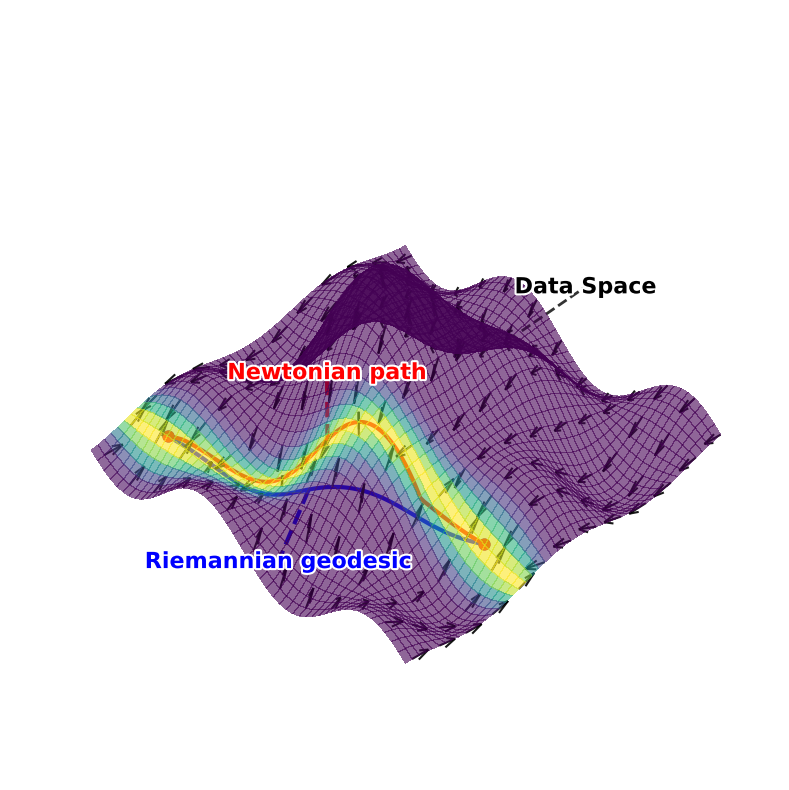

In [15]:
# -------------------------
# 9. Plot manifold
# -------------------------
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X, Y, Z_np,
    facecolors=plt.cm.get_cmap(cmap_style)(strip_np),
    rstride=1,
    cstride=1,
    linewidth=0,
    edgecolor='none',
    antialiased=False,
    shade=False,
    alpha=0.6,
    zorder=0
)

# -------------------------
# 10. Vector field
# -------------------------
step = 4  # subsample factor
Xq = X[::step, ::step].ravel()
Yq = Y[::step, ::step].ravel()
Zq = Z_np[::step, ::step].ravel()

Uq = grad_X[::step, ::step].ravel()
Vq = grad_Y[::step, ::step].ravel()
Wq = grad_Z[::step, ::step].ravel()

dx = np.mean(np.diff(X[::step, 0]))
dy = np.mean(np.diff(Y[0, ::step]))
arrow_length = 0.6 * np.mean([dx, dy])

ax.quiver(
    Xq, Yq, Zq,
    Uq, Vq, Wq,
    color='black',
    length=arrow_length,
    normalize=True,
    alpha=0.9,
    zorder=1,
    arrow_length_ratio=0.6,
)

# -------------------------
# 11. Plot curves on the manifold
# -------------------------
# Map curves to the manifold
rm_curve_xyz = manifold_mapping(rm_curve)  # Riemannian geodesic
lam_curve_xyz = manifold_mapping(lam_curve)  # Newtonian path

rm_curve_xyz_np = rm_curve_xyz.detach().cpu().numpy()
lam_curve_xyz_np = lam_curve_xyz.detach().cpu().numpy()

# Plot the curves
ax.plot3D(rm_curve_xyz_np[:, 0], rm_curve_xyz_np[:, 1], rm_curve_xyz_np[:, 2], color='blue', linewidth=3, zorder=2)
ax.plot3D(lam_curve_xyz_np[:, 0], lam_curve_xyz_np[:, 1], lam_curve_xyz_np[:, 2], color='red', linewidth=3, zorder=2)

# -------------------------
# 12. Add labels with lines pointing to curves
# -------------------------
# Riemannian geodesic label (under the curve)
label_point = rm_curve_xyz_np[len(rm_curve_xyz_np)//2]
text_offset = np.array([0.2, 0.2, -0.3])  # negative z for under the curve
text_pos = label_point + text_offset

# -------------------------
# 13. Highlight start and end points
# -------------------------
ax.scatter(rm_curve_xyz_np[0, 0], rm_curve_xyz_np[0, 1], rm_curve_xyz_np[0, 2],
           color='blue', s=60, zorder=2)
ax.scatter(rm_curve_xyz_np[-1, 0], rm_curve_xyz_np[-1, 1], rm_curve_xyz_np[-1, 2],
           color='blue', s=60, zorder=2)

ax.scatter(lam_curve_xyz_np[0, 0], lam_curve_xyz_np[0, 1], lam_curve_xyz_np[0, 2],
           color='red', s=60, zorder=2)
ax.scatter(lam_curve_xyz_np[-1, 0], lam_curve_xyz_np[-1, 1], lam_curve_xyz_np[-1, 2],
           color='red', s=60, zorder=2)

# -------------------------
# 14. Add labels with lines pointing to curves (centered, dotted)
# -------------------------

# --- Riemannian geodesic label (slightly lower) ---
label_point = rm_curve_xyz_np[len(rm_curve_xyz_np)//2]
text_offset = np.array([0.2, 0.2, -0.5])
text_pos = label_point + text_offset
line_target = text_pos.copy()

ax.plot(
    [label_point[0], line_target[0]],
    [label_point[1], line_target[1]],
    [label_point[2], line_target[2]],
    color='blue', linewidth=3, linestyle='--', alpha=1.0  # dotted line
)

ax.text(
    text_pos[0], text_pos[1], text_pos[2],
    "Riemannian geodesic",
    color='blue',
    fontsize=16,
    fontweight='bold',
    zorder=10,
    ha='center', va='center',
    path_effects=[path_effects.withStroke(linewidth=3, foreground="white")]
)

# --- Newtonian path label (above curve) ---
label_point2 = lam_curve_xyz_np[len(lam_curve_xyz_np)//2]
text_offset2 = np.array([0.2, -0.2, 0.3])
text_pos2 = label_point2 + text_offset2
line_target2 = text_pos2.copy()

ax.plot(
    [label_point2[0], line_target2[0]],
    [label_point2[1], line_target2[1]],
    [label_point2[2], line_target2[2]],
    color='red', linewidth=3, linestyle='--', alpha=1.0  # dotted line
)

ax.text(
    text_pos2[0], text_pos2[1], text_pos2[2],
    "Newtonian path",
    color='red',
    fontsize=16,
    fontweight='bold',
    zorder=10,
    ha='center', va='center',
    path_effects=[path_effects.withStroke(linewidth=3, foreground="white")]
)

# --- Data Space label pointing to manifold ---
manifold_point = np.array([0.0, -1.5, Z_np[25, 10]])
text_offset3 = np.array([-0.4, -0.4, 0.3])
text_pos3 = manifold_point + text_offset3
line_target3 = text_pos3.copy()

ax.plot(
    [manifold_point[0], line_target3[0]],
    [manifold_point[1], line_target3[1]],
    [manifold_point[2], line_target3[2]],
    color='black', linewidth=2, linestyle='--', alpha=0.8  # dotted line
)

ax.text(
    text_pos3[0], text_pos3[1], text_pos3[2],
    "Data Space",
    color='black',
    fontsize=16,
    fontweight='bold',
    zorder=10,
    ha='center', va='center',
    path_effects=[path_effects.withStroke(linewidth=3, foreground="white")]
)





# -------------------------
# 13. Labels and view
# -------------------------

ax.view_init(elev=42.5, azim=135)  # slightly higher look
ax.set_box_aspect((1, 1, 0.6))
ax.dist = 9

ax.set_axis_off()

plt.tight_layout()

save_path = f'{figure_path}path_illustration.pdf'
fig.savefig(save_path, format='pdf', pad_inches=0.1, bbox_inches='tight')

plt.show()


In [16]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def draw_arrow(ax, start, vec, length=0.1, color='black'):
    """
    Draw a 3D arrow with a visible cone head.
    start: (x, y, z) array
    vec: (u, v, w) array
    length: length of the cone
    """
    import numpy as np
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection
    
    # Normalize vector
    vec = np.array(vec)
    vec_norm = np.linalg.norm(vec)
    if vec_norm == 0:
        return
    vec_unit = vec / vec_norm
    
    # Tip of arrow
    tip = start + vec_unit * length
    
    # Draw shaft
    ax.plot([start[0], tip[0]],
            [start[1], tip[1]],
            [start[2], tip[2]],
            color=color, linewidth=1.5)
    
    # Draw cone at tip (simple triangular approximation)
    # Pick arbitrary perpendicular vectors
    if vec_unit[0] != 0 or vec_unit[1] != 0:
        perp1 = np.array([-vec_unit[1], vec_unit[0], 0])
    else:
        perp1 = np.array([1, 0, 0])
    perp1 = perp1 / np.linalg.norm(perp1)
    perp2 = np.cross(vec_unit, perp1)
    
    cone_radius = 0.2 * length
    n_sides = 6
    cone_pts = []
    for i in range(n_sides):
        angle = 2 * np.pi * i / n_sides
        point = tip + cone_radius * (np.cos(angle) * perp1 + np.sin(angle) * perp2)
        cone_pts.append(point)
    # Add the tip point to each triangle
    for i in range(n_sides):
        triangle = [tip, cone_pts[i], cone_pts[(i+1)%n_sides]]
        ax.add_collection3d(Poly3DCollection([triangle], color=color))


/tmp/ipykernel_10453/4029549849.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  facecolors=plt.cm.get_cmap(cmap_style)(strip_np),


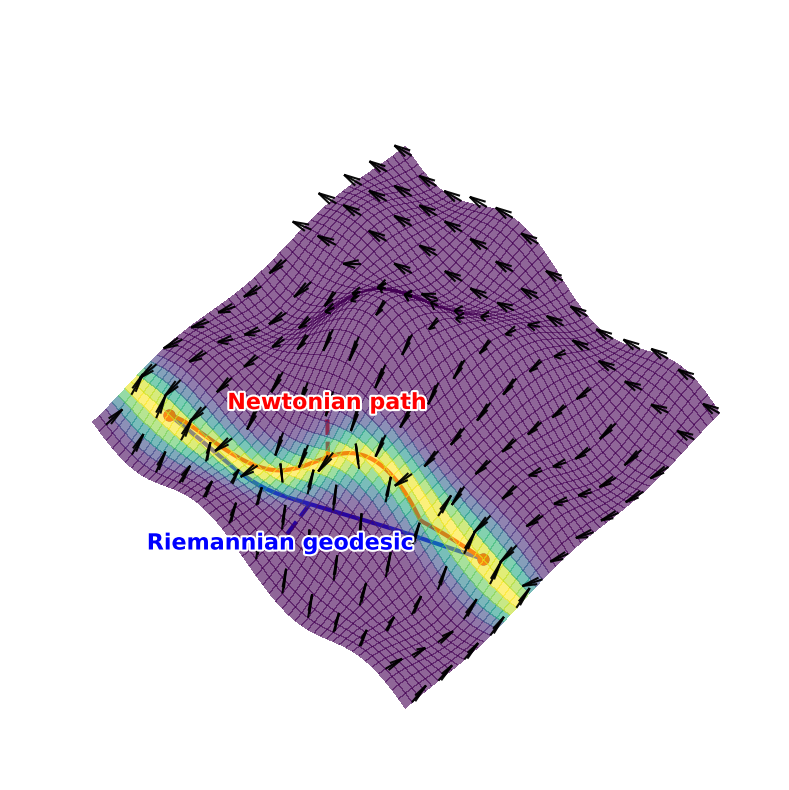

In [17]:
# -------------------------
# 9. Plot manifold
# -------------------------
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X, Y, Z_np,
    facecolors=plt.cm.get_cmap(cmap_style)(strip_np),
    rstride=1,
    cstride=1,
    linewidth=0,
    edgecolor='none',
    antialiased=False,
    shade=False,
    alpha=0.6,
    zorder=0
)

# -------------------------
# 10. Vector field
# -------------------------
step = 4  # subsample factor
Xq = X[::step, ::step].ravel()
Yq = Y[::step, ::step].ravel()
Zq = Z_np[::step, ::step].ravel()

Uq = grad_X[::step, ::step].ravel()
Vq = grad_Y[::step, ::step].ravel()
Wq = grad_Z[::step, ::step].ravel()

dx = np.mean(np.diff(X[::step, 0]))
dy = np.mean(np.diff(Y[0, ::step]))
arrow_length = 0.6 * np.mean([dx, dy])


# Optional: add a small component toward camera so arrowheads face viewer
# Compute view vector
elev = np.deg2rad(42.5)
azim = np.deg2rad(135)
view_dir = np.array([np.cos(elev)*np.cos(azim), np.cos(elev)*np.sin(azim), np.sin(elev)])

bias_strength = 0.2  # smaller than before
Uq_b = Uq + bias_strength * view_dir[0]
Vq_b = Vq + bias_strength * view_dir[1]
Wq_b = Wq + bias_strength * view_dir[2]

ax.quiver(
    Xq, Yq, Zq,
    Uq + 0.1, Vq + 0.1, Wq + 0.1,
    color='black',
    length=arrow_length,
    normalize=True,
    linewidth=1.5,
    arrow_length_ratio=0.8,
    pivot='tail',
    alpha=0.95,
    zorder=5
)



# -------------------------
# 11. Plot curves on the manifold
# -------------------------
# Map curves to the manifold
rm_curve_xyz = manifold_mapping(rm_curve)  # Riemannian geodesic
lam_curve_xyz = manifold_mapping(lam_curve)  # Newtonian path

rm_curve_xyz_np = rm_curve_xyz.detach().cpu().numpy()
lam_curve_xyz_np = lam_curve_xyz.detach().cpu().numpy()

# Plot the curves
ax.plot3D(rm_curve_xyz_np[:, 0], rm_curve_xyz_np[:, 1], rm_curve_xyz_np[:, 2], color='blue', linewidth=3, zorder=2)
ax.plot3D(lam_curve_xyz_np[:, 0], lam_curve_xyz_np[:, 1], lam_curve_xyz_np[:, 2], color='red', linewidth=3, zorder=2)

# -------------------------
# 12. Add labels with lines pointing to curves
# -------------------------
# Riemannian geodesic label (under the curve)
label_point = rm_curve_xyz_np[len(rm_curve_xyz_np)//2]
text_offset = np.array([0.2, 0.2, -0.3])  # negative z for under the curve
text_pos = label_point + text_offset

# -------------------------
# 13. Highlight start and end points
# -------------------------
ax.scatter(rm_curve_xyz_np[0, 0], rm_curve_xyz_np[0, 1], rm_curve_xyz_np[0, 2],
           color='blue', s=60, zorder=2)
ax.scatter(rm_curve_xyz_np[-1, 0], rm_curve_xyz_np[-1, 1], rm_curve_xyz_np[-1, 2],
           color='blue', s=60, zorder=2)

ax.scatter(lam_curve_xyz_np[0, 0], lam_curve_xyz_np[0, 1], lam_curve_xyz_np[0, 2],
           color='red', s=60, zorder=2)
ax.scatter(lam_curve_xyz_np[-1, 0], lam_curve_xyz_np[-1, 1], lam_curve_xyz_np[-1, 2],
           color='red', s=60, zorder=2)

# -------------------------
# 14. Add labels with lines pointing to curves (centered, dotted)
# -------------------------

# --- Riemannian geodesic label (slightly lower) ---
label_point = rm_curve_xyz_np[len(rm_curve_xyz_np)//2]
text_offset = np.array([0.2, 0.2, -0.5])
text_pos = label_point + text_offset
line_target = text_pos.copy()

ax.plot(
    [label_point[0], line_target[0]],
    [label_point[1], line_target[1]],
    [label_point[2], line_target[2]],
    color='blue', linewidth=3, linestyle='--', alpha=1.0  # dotted line
)

ax.text(
    text_pos[0], text_pos[1], text_pos[2],
    "Riemannian geodesic",
    color='blue',
    fontsize=16,
    fontweight='bold',
    zorder=10,
    ha='center', va='center',
    path_effects=[path_effects.withStroke(linewidth=3, foreground="white")]
)

# --- Newtonian path label (above curve) ---
label_point2 = lam_curve_xyz_np[len(lam_curve_xyz_np)//2]
text_offset2 = np.array([0.2, -0.2, 0.3])
text_pos2 = label_point2 + text_offset2
line_target2 = text_pos2.copy()

ax.plot(
    [label_point2[0], line_target2[0]],
    [label_point2[1], line_target2[1]],
    [label_point2[2], line_target2[2]],
    color='red', linewidth=3, linestyle='--', alpha=1.0  # dotted line
)

ax.text(
    text_pos2[0], text_pos2[1], text_pos2[2],
    "Newtonian path",
    color='red',
    fontsize=16,
    fontweight='bold',
    zorder=10,
    ha='center', va='center',
    path_effects=[path_effects.withStroke(linewidth=3, foreground="white")]
)

# --- Data Space label pointing to manifold ---
manifold_point = np.array([0.0, -1.5, Z_np[25, 10]])
text_offset3 = np.array([-0.4, -0.4, 0.3])
text_pos3 = manifold_point + text_offset3
line_target3 = text_pos3.copy()

#ax.plot(
#    [manifold_point[0], line_target3[0]],
#    [manifold_point[1], line_target3[1]],
#    [manifold_point[2], line_target3[2]],
#    color='black', linewidth=2, linestyle='--', alpha=0.8  # dotted line
#)

#ax.text(
#    text_pos3[0], text_pos3[1], text_pos3[2],
#    "Data Space",
#    color='black',
#    fontsize=16,
#    fontweight='bold',
#    zorder=10,
#    ha='center', va='center',
#    path_effects=[path_effects.withStroke(linewidth=3, foreground="white")]
#)





# -------------------------
# 13. Labels and view
# -------------------------

#ax.view_init(elev=42.5, azim=135)  # slightly higher look
ax.view_init(elev=65, azim=135)  # slightly higher look
ax.set_box_aspect((1, 1, 0.6))
ax.dist = 9

ax.set_axis_off()

plt.tight_layout()

save_path = f'{figure_path}path_illustration.pdf'
fig.savefig(save_path, format='pdf', pad_inches=0.1, bbox_inches='tight')

plt.show()
